# Spatial and Temporal Split Visualisation

This notebook visualises the split functions built in `models/common/splits.py` and
`models/common/geo.py`. It does not reimplement any split logic — every split shown
here is produced by importing the real functions used by the model scripts, so what
you see is exactly what those scripts do, just with maps added.

Covers:
1. Plot coordinates (centroids of the 20m/40m grid cells, from the raw GeoPackage)
2. Why a random/plot-level split leaks spatially, shown on a map
3. `spatial_block_split()` — whole compartments (`cpmt`) held out, visualised
4. `spatial_block_split()` with `buffer_distance` — edge exclusion zone visualised
5. `temporal_split()` — row counts per split, by year
6. Saving the split assignments as CSV, for now, so they can be reloaded without rerunning this notebook

In [1]:
# Purpose: Make the models/ package importable from this notebook.
# Key logic: Walk upward from the current folder until a folder containing
# both README.md and data/ is found — that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from models.common.geo import find_train_plots_near_holdout, load_plot_coordinates
from models.common.splits import plot_level_split, spatial_block_split, temporal_split

pd.set_option("display.max_columns", 50)

COHORTS = ["4survey", "6survey"]

# One consistent colour per split label, used in every map/chart below.
SPLIT_COLORS = {
    "train": "#1f77b4",
    "val": "#ff7f0e",
    "test": "#2ca02c",
    "buffer": "#999999",
    "unassigned": "#dddddd",
}

## 1. Load plot coordinates and master data

`plot_coordinates.csv.gz` is built once by `models/common/export_coordinates.py` and holds
one centroid (x, y, in EPSG:27700 metres) per plot. It is joined onto each cohort's master
table here just for plotting — the model scripts do this same join internally when a buffer
distance is requested.

In [3]:
coordinates_df = load_plot_coordinates()
print(f"{len(coordinates_df):,} plot coordinates loaded")

master = {}
for cohort in COHORTS:
    master_path = project_root / "data" / "processed" / "master" / f"clean_master_{cohort}.parquet"
    cohort_df = pd.read_parquet(master_path)
    cohort_df = cohort_df.merge(coordinates_df, on="identification", how="left")
    master[cohort] = cohort_df

    n_with_coords = cohort_df["x"].notna().sum()
    print(f"{cohort}: {len(cohort_df):,} rows, {n_with_coords:,} have coordinates ({n_with_coords / len(cohort_df):.1%})")

230,359 plot coordinates loaded
4survey: 287,064 rows, 287,064 have coordinates (100.0%)
6survey: 83,382 rows, 83,382 have coordinates (100.0%)


## 2. Map of all plots, coloured by block (`blk`)

`blk` only has 8 values across the whole estate. This is why `blk` is too coarse to use as
the block for `spatial_block_split()` — the map below shows just how large and uneven those
8 areas are. `cpmt` (compartment) is used instead, further down.

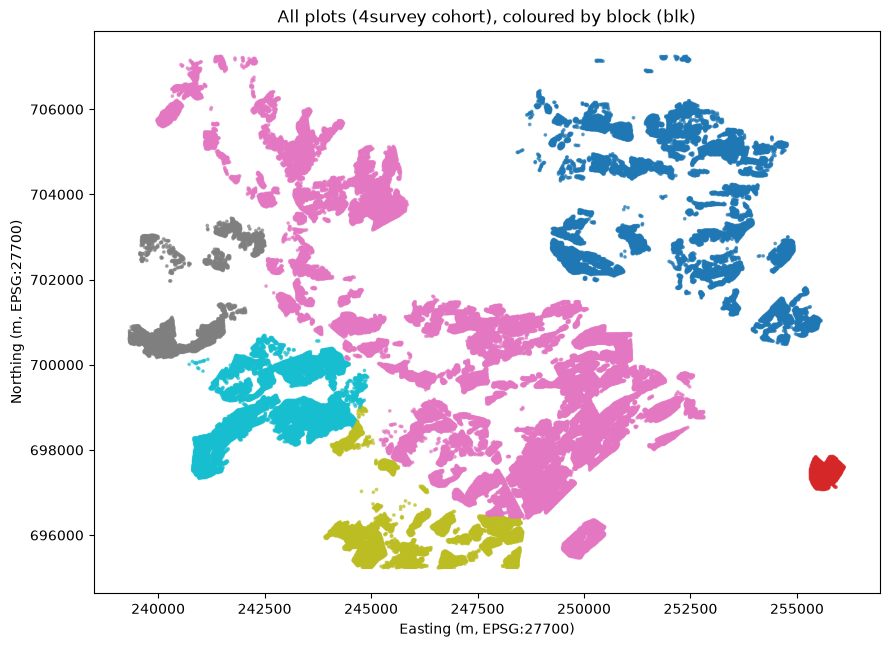

In [4]:
unique_plots_4survey = master["4survey"].drop_duplicates("identification")

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    unique_plots_4survey["x"], unique_plots_4survey["y"],
    c=unique_plots_4survey["blk"], cmap="tab10", s=3, alpha=0.6,
)
ax.set_title("All plots (4survey cohort), coloured by block (blk)")
ax.set_xlabel("Easting (m, EPSG:27700)")
ax.set_ylabel("Northing (m, EPSG:27700)")
ax.set_aspect("equal")
legend = ax.legend(*scatter.legend_elements(), title="blk", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend)
plt.tight_layout()
plt.show()

## 3. Why a random/plot-level split leaks spatially

`plot_level_split()` shuffles individual plots at random. On a map, that means train/val/test
are mixed together everywhere — a plot can sit right next to a plot from a different split.
Since neighbouring plots share near-identical terrain and wind exposure, a model can "cheat"
by picking up local conditions rather than genuinely learning from them.

In [5]:
def plot_split_map(df, split_col, title, ax):
    for split_name, color in SPLIT_COLORS.items():
        subset = df[df[split_col] == split_name]
        if len(subset) == 0:
            continue
        ax.scatter(subset["x"], subset["y"], c=color, s=3, alpha=0.6, label=split_name)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    ax.legend(markerscale=4, loc="upper left", bbox_to_anchor=(1.02, 1))

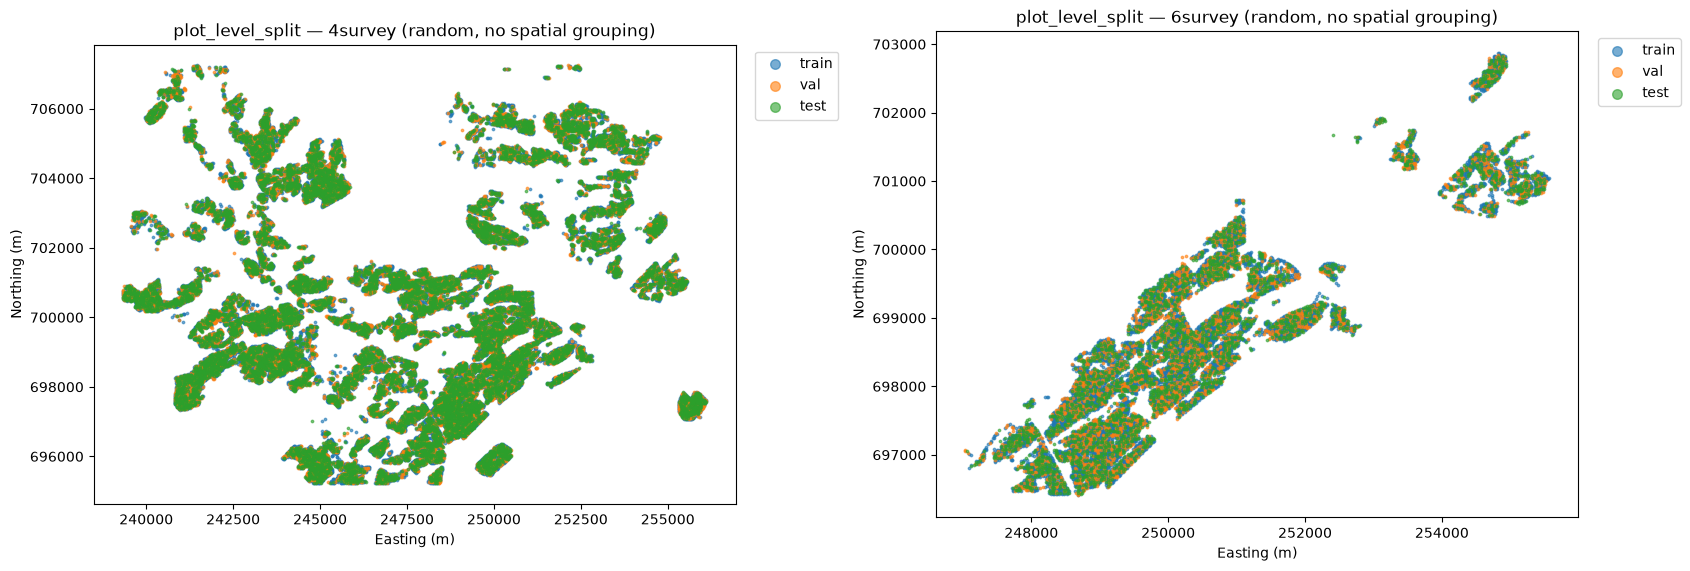

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, cohort in zip(axes, COHORTS):
    df = master[cohort].drop_duplicates("identification").copy()
    df["plot_split"] = plot_level_split(df, seed=42)
    plot_split_map(df, "plot_split", f"plot_level_split — {cohort} (random, no spatial grouping)", ax)

plt.tight_layout()
plt.show()

## 4. `spatial_block_split()` — whole compartments held out

Compare this to the map above: here, `cpmt` (compartment) is the split unit, so every plot in
a compartment goes to the same split. The result should look like solid, contiguous patches
of colour rather than a random speckle.

4survey: train=42,066, val=14,990, test=14,710
6survey: train=7,963, val=2,819, test=3,115


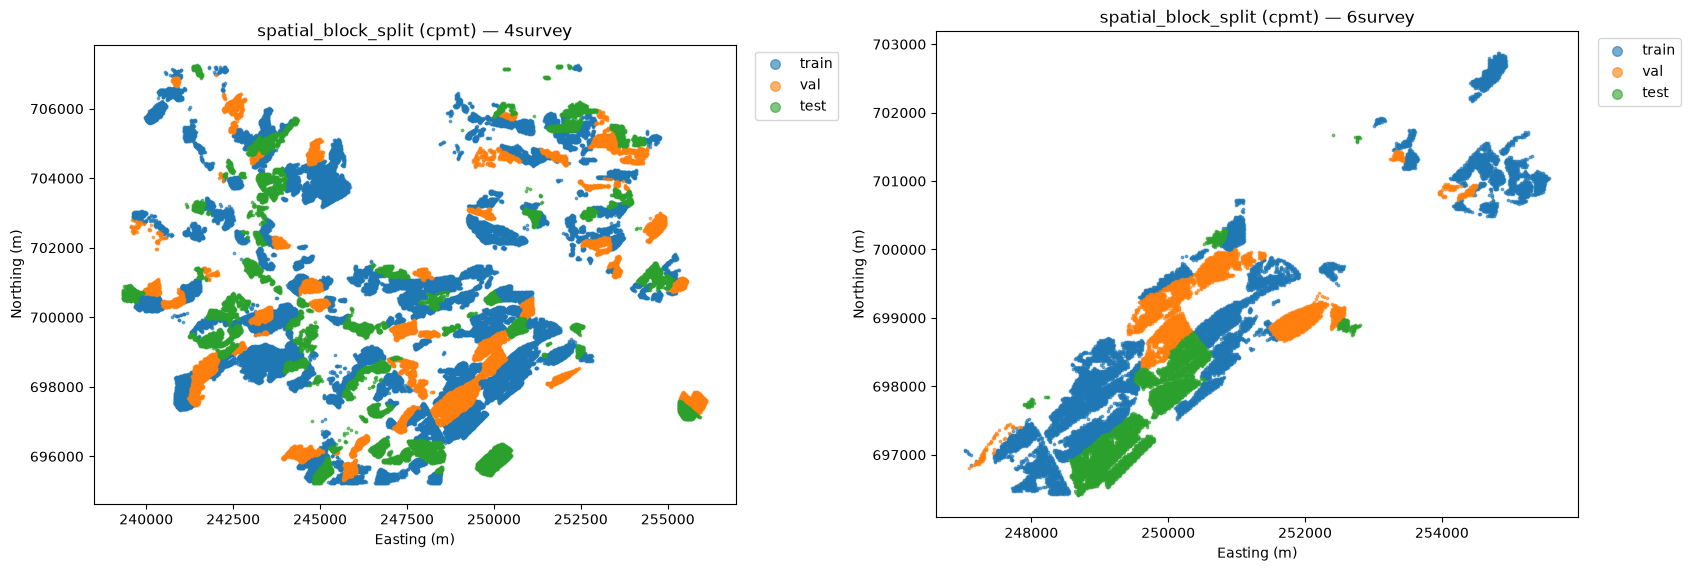

In [7]:
spatial_split_dfs = {}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, cohort in zip(axes, COHORTS):
    df = master[cohort].drop_duplicates("identification").copy()
    df["spatial_split"] = spatial_block_split(df, block_col="cpmt", coordinates_df=coordinates_df, seed=42)
    spatial_split_dfs[cohort] = df

    plot_split_map(df, "spatial_split", f"spatial_block_split (cpmt) — {cohort}", ax)

    counts = df["spatial_split"].value_counts()
    print(f"{cohort}: " + ", ".join(f"{name}={counts.get(name, 0):,}" for name in ["train", "val", "test"]))

plt.tight_layout()
plt.show()

## 5. `spatial_block_split()` with `buffer_distance` — edge exclusion visualised

Even with whole compartments held out, a plot right on the edge of a compartment can still sit
physically close to a plot in a different split. `buffer_distance` finds every **train** plot within
that distance of a **val/test** plot and excludes it (shown in grey below). Buffering is asymmetric on
purpose: leakage only happens when a plot the model *trains on* sits next to a plot it is *evaluated
on* — two held-out plots sitting near each other causes no leakage, since neither one updates the
model. So val and test are never touched here; they always keep every plot the block assignment gave
them, and only train gets thinned near a held-out boundary.

  Buffer: 3,284 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
4survey: train=38,782, val=14,990, test=14,710, buffer=3,284
  Buffer: 496 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
6survey: train=7,467, val=2,819, test=3,115, buffer=496


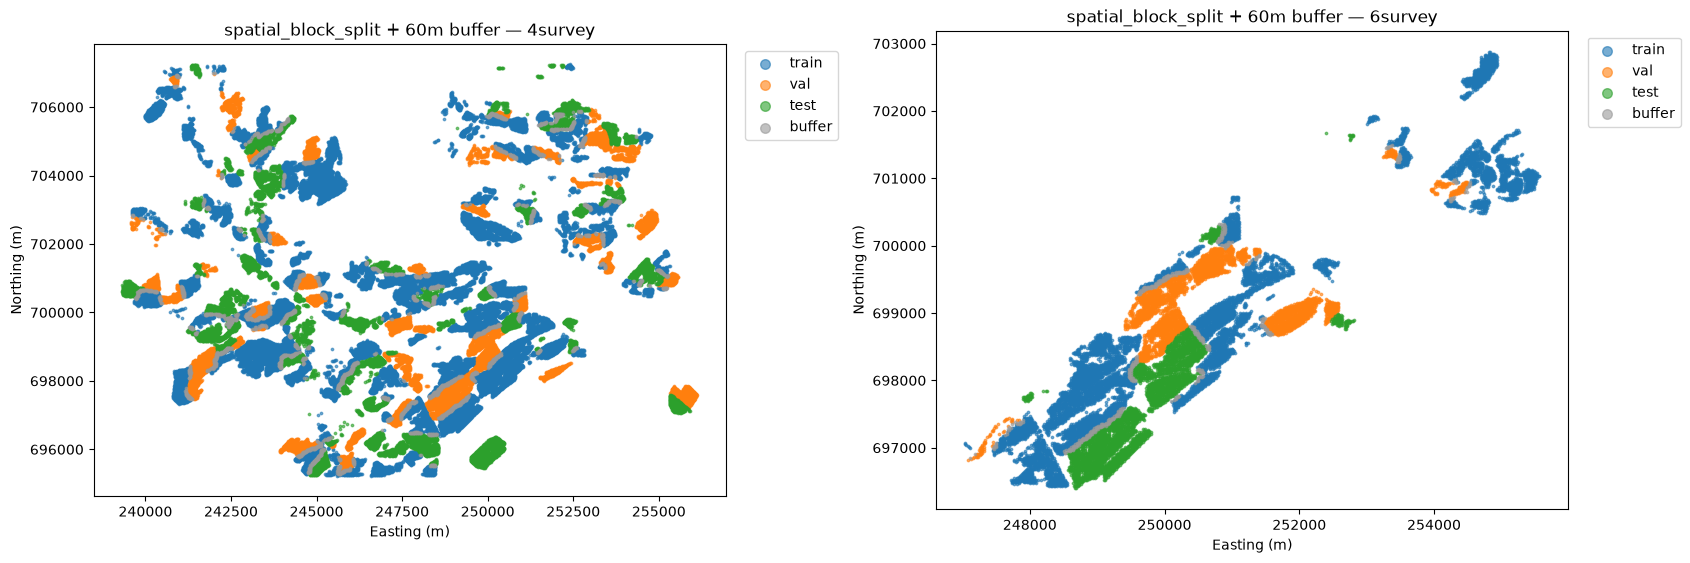

In [8]:
BUFFER_DISTANCE_METRES = 60  # most plots are 20m grid cells, so 60m is a clean 3-cell-width buffer

buffered_split_dfs = {}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, cohort in zip(axes, COHORTS):
    df = master[cohort].drop_duplicates("identification").copy()
    df["buffered_split"] = spatial_block_split(
        df, block_col="cpmt", buffer_distance=BUFFER_DISTANCE_METRES,
        coordinates_df=coordinates_df, seed=42,
    )
    buffered_split_dfs[cohort] = df

    plot_split_map(df, "buffered_split", f"spatial_block_split + {BUFFER_DISTANCE_METRES}m buffer — {cohort}", ax)

    counts = df["buffered_split"].value_counts()
    print(
        f"{cohort}: " + ", ".join(
            f"{name}={counts.get(name, 0):,}" for name in ["train", "val", "test", "buffer"]
        )
    )

plt.tight_layout()
plt.show()

In [9]:
# Sanity check: after buffering, no remaining TRAIN plot should be within
# BUFFER_DISTANCE_METRES of a val/test plot. val/test are never touched by
# buffering, so they are not re-checked against each other here — two
# held-out plots sitting near each other is not a leak.
for cohort in COHORTS:
    df = buffered_split_dfs[cohort]
    plot_to_split = dict(zip(df["identification"], df["buffered_split"]))
    plot_to_split = {plot_id: split for plot_id, split in plot_to_split.items() if split != "buffer"}

    still_too_close = find_train_plots_near_holdout(coordinates_df, plot_to_split, BUFFER_DISTANCE_METRES)
    status = "OK" if len(still_too_close) == 0 else "FAIL"
    print(f"{cohort}: {status} — {len(still_too_close):,} train plots still within {BUFFER_DISTANCE_METRES}m of a val/test plot")

4survey: OK — 0 train plots still within 60m of a val/test plot
6survey: OK — 0 train plots still within 60m of a val/test plot


### Why some buffer zones look wider than 60m on the map

With asymmetric buffering, **only train compartments can lose any plots at all** — a compartment
originally assigned to val or test is never touched, so its buffered fraction is always exactly 0%.
That already rules out one possible explanation (a val/test compartment "eroding" from both sides);
whatever width is visible only ever comes from the train side of a boundary.

Two things can still make a *train* compartment's buffer zone look wide: (1) the compartment itself is
small or narrow, so a 60m rim reaches all the way across it, or (2) the compartment shares a long or
irregular border with val/test, so a large chunk of its train plots sit within range even though the
compartment is not narrow overall. Both are measurable directly from the coordinates already loaded,
without needing the compartment polygon geometry: for each `cpmt`, take the bounding box of its plot
centroids as a rough size proxy, and compare it against how much of that compartment actually got
buffered.

In [10]:
def compartment_buffer_summary(buffered_df, unbuffered_df, block_col="cpmt"):
    # Bounding-box extent of each compartment's plot centroids, as a simple
    # size proxy (no polygon geometry needed), plus how much of that
    # compartment ended up buffered and which split it was originally
    # assigned to (val/test compartments are always 0% buffered now, so
    # they're tracked here to filter them out of the "which train
    # compartments lose the most" analysis below).
    grouped = buffered_df.groupby(block_col).agg(
        n_plots=("identification", "count"),
        n_buffered=("buffered_split", lambda s: (s == "buffer").sum()),
        x_min=("x", "min"), x_max=("x", "max"),
        y_min=("y", "min"), y_max=("y", "max"),
    ).copy()

    original_split_by_compartment = unbuffered_df.groupby(block_col)["spatial_split"].first()
    grouped["original_split"] = original_split_by_compartment

    grouped["buffered_fraction"] = grouped["n_buffered"] / grouped["n_plots"]
    grouped["extent_x"] = grouped["x_max"] - grouped["x_min"]
    grouped["extent_y"] = grouped["y_max"] - grouped["y_min"]
    # The narrower of the two bounding-box sides — this is the dimension a
    # long shared border can consume the most of.
    grouped["narrower_extent"] = grouped[["extent_x", "extent_y"]].min(axis=1)

    return grouped.drop(columns=["x_min", "x_max", "y_min", "y_max"])


compartment_summaries = {}
for cohort in COHORTS:
    compartment_summaries[cohort] = compartment_buffer_summary(buffered_split_dfs[cohort], spatial_split_dfs[cohort])
    n_total = len(compartment_summaries[cohort])
    n_train = (compartment_summaries[cohort]["original_split"] == "train").sum()
    print(f"{cohort}: {n_total:,} compartments summarised ({n_train:,} originally train, the only ones that can show any buffering)")

4survey: 296 compartments summarised (176 originally train, the only ones that can show any buffering)
6survey: 48 compartments summarised (31 originally train, the only ones that can show any buffering)


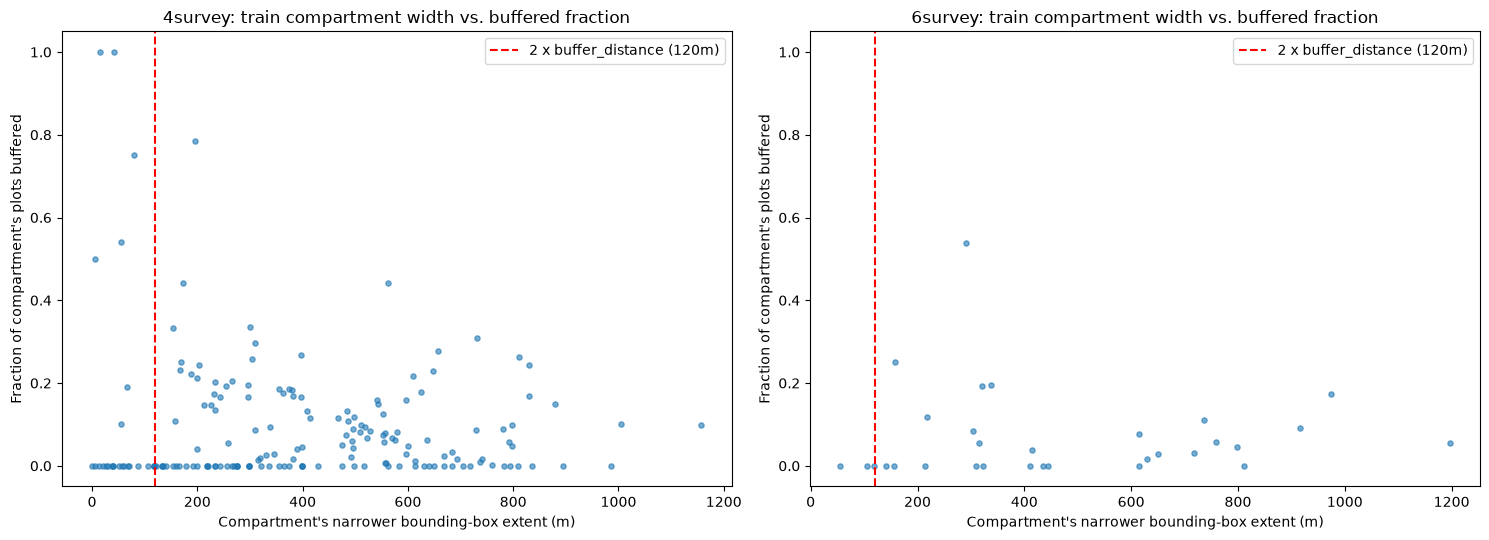

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, cohort in zip(axes, COHORTS):
    # Only train compartments can have any buffered plots now, so val/test
    # compartments (always exactly 0%) are excluded here to avoid cluttering
    # the plot with a flat line of points that aren't part of this question.
    summary = compartment_summaries[cohort]
    train_summary = summary[summary["original_split"] == "train"]

    ax.scatter(train_summary["narrower_extent"], train_summary["buffered_fraction"], s=14, alpha=0.6)
    ax.axvline(
        2 * BUFFER_DISTANCE_METRES, color="red", linestyle="--",
        label=f"2 x buffer_distance ({2 * BUFFER_DISTANCE_METRES}m)",
    )
    ax.set_title(f"{cohort}: train compartment width vs. buffered fraction")
    ax.set_xlabel("Compartment's narrower bounding-box extent (m)")
    ax.set_ylabel("Fraction of compartment's plots buffered")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()

In [12]:
for cohort in COHORTS:
    summary = compartment_summaries[cohort]
    train_summary = summary[summary["original_split"] == "train"]

    narrow_threshold = 2 * BUFFER_DISTANCE_METRES
    narrow_compartments = train_summary[train_summary["narrower_extent"] < narrow_threshold]
    wide_compartments = train_summary[train_summary["narrower_extent"] >= narrow_threshold]
    fully_buffered = train_summary[train_summary["buffered_fraction"] >= 0.99]

    print(f"{cohort} (train compartments only — val/test are always 0% buffered):")
    print(
        f"  {len(narrow_compartments):,} / {len(train_summary):,} train compartments are narrower than "
        f"{narrow_threshold}m on their short side"
    )
    print(
        f"  Of those, mean buffered fraction = {narrow_compartments['buffered_fraction'].mean():.1%} "
        f"vs {wide_compartments['buffered_fraction'].mean():.1%} for wider train compartments"
    )
    print(f"  {len(fully_buffered):,} train compartments are >=99% buffered (visually read as solid grey)")

    print("  Most heavily buffered train compartments:")
    display(
        train_summary.sort_values("buffered_fraction", ascending=False)
        .head(5)[["n_plots", "n_buffered", "buffered_fraction", "narrower_extent"]]
    )
    print()

4survey (train compartments only — val/test are always 0% buffered):
  26 / 176 train compartments are narrower than 120m on their short side
  Of those, mean buffered fraction = 15.7% vs 8.7% for wider train compartments
  2 train compartments are >=99% buffered (visually read as solid grey)
  Most heavily buffered train compartments:


,n_plots,n_buffered,buffered_fraction,narrower_extent
cpmt,,,,
2059,8,8,1.000000,41.531578
1059,2,2,1.000000,14.717902
2259,14,11,0.785714,195.106587
1138,4,3,0.750000,79.357463
1133,24,13,0.541667,55.809843



6survey (train compartments only — val/test are always 0% buffered):
  3 / 31 train compartments are narrower than 120m on their short side
  Of those, mean buffered fraction = 0.0% vs 7.7% for wider train compartments
  0 train compartments are >=99% buffered (visually read as solid grey)
  Most heavily buffered train compartments:


,n_plots,n_buffered,buffered_fraction,narrower_extent
cpmt,,,,
2216,119,64,0.537815,290.267567
2212,8,2,0.250000,157.147027
2182,282,55,0.195035,338.504825
2188,114,22,0.192982,320.983109
2252,706,123,0.174221,974.520402


**Restricting to train compartments (the only ones that can be buffered now) still only partly
supports the "narrow compartment" hypothesis** — worth reporting honestly rather than overclaiming.
For 4survey, narrow train compartments (<120m) do have a higher mean buffered fraction (15.7% vs
8.7%), and the 2 fully-buffered ones genuinely are tiny (41m and 15m across). But 6survey's narrow
train compartments average *0%* buffered, the opposite of the hypothesis, while several of the most
heavily-buffered train compartments in both cohorts are actually **wide** by bounding box (up to
974m for 6survey's `cpmt` 2252, a 706-plot compartment that still loses 17% of its plots) while still
losing a meaningful fraction.

The likely reason: a rectangular bounding box is a crude size proxy. A long, thin, L-shaped, or
crescent-shaped compartment can have a large bounding box while still being narrow along most of its
actual footprint, or it can simply border many val/test compartments along a long perimeter — neither
of which the bounding-box extent captures. So both mechanisms are real: (1) genuinely small train
compartments can lose their whole footprint to the buffer, and (2) train compartments with an
irregular shape or an unusually long shared border with val/test can still lose a large fraction even
when "wide" by bounding box. Getting a precise answer would need the actual compartment polygon
geometry (not loaded here, since the buffer logic itself only ever needs point coordinates) rather
than this bounding-box proxy. Either way, the practical consequence is now much smaller than before —
only train pays this cost, never val or test.

### Roughly how big is each split with this method?

Plot-level counts, `cpmt` as the block, seed=42 (from the cells above):

| | train | val | test | buffer |
|---|---|---|---|---|
| **4survey, no buffer** | 42,066 (58.6%) | 14,990 (20.9%) | 14,710 (20.5%) | — |
| **4survey, 60m buffer** | 38,782 (54.0%) | 14,990 (20.9%) | 14,710 (20.5%) | 3,284 (4.6%) |
| **6survey, no buffer** | 7,963 (57.3%) | 2,819 (20.3%) | 3,115 (22.4%) | — |
| **6survey, 60m buffer** | 7,467 (53.7%) | 2,819 (20.3%) | 3,115 (22.4%) | 496 (3.6%) |

val and test are **identical** with or without the buffer — that's the point of buffering only the
train side (see the next section). Only train shrinks, and by a small amount (7.8% of its own rows
for 4survey, 6.2% for 6survey) — a much smaller cost than the earlier symmetric version, which also
stripped plots out of val and test.

### How the buffer actually decides what to exclude

Worth being precise about the mechanism, since "near a compartment boundary" is a description of the
*effect*, not the *rule* being applied. The buffer does **not** look at `cpmt` polygon boundaries at
all — compartment boundary geometry is never loaded. Instead, after compartments have already been
assigned to train/val/test, `find_train_plots_near_holdout()` (`models/common/geo.py`) does a purely
distance-based check:

1. Build one KDTree of the val/test plot centroids (combined — both are "held out").
2. For every **train** plot, query that tree for its nearest held-out neighbour.
3. If that distance is under `buffer_distance`, the train plot is relabelled `"buffer"`.

**val and test plots are never checked or excluded** — this is asymmetric on purpose. Leakage only
happens when a plot the model *trains on* sits next to a plot it is *evaluated on*; two held-out plots
sitting near each other causes no leakage, since neither one ever updates the model. Buffering only
the train side means val and test always keep every plot the block assignment gave them, no matter how
large or irregular a border a compartment happens to share with another split — a compartment made
entirely of val/test plots can never lose a single row to buffering, however long its boundary is.

(An earlier version of this buffer excluded plots from *all* splits symmetrically, which meant a
val/test compartment with a long or irregular shared border could lose a large fraction of its own
plots — see the compartment-width analysis below, whose numbers now reflect the asymmetric version.)

### Idea for later: using neighbouring-plot canopy cover as a shelter/exposure proxy

Raised as a fallback in case terrain/wind data (WASP, OS Terrain 50, Global Wind Atlas — still pending
per the Data Access Checklist) is delayed or insufficient: the same centroid infrastructure used for
the buffer here (`load_plot_coordinates()` + KDTree) could compute, for each plot, an aggregate of its
*neighbours'* `CanopyCover` within some radius — e.g. mean neighbour canopy cover, or a canopy-cover
gradient (this plot's canopy cover minus its neighbourhood's) as a crude "am I at a windward/open edge
or sheltered mid-stand" signal, without waiting on any external terrain/wind source.

This is a genuinely reasonable idea — edge exposure and windthrow risk at stand boundaries is
well-established in forestry (Gardiner et al., ForestGALES literature), so a nearby-canopy-gap signal
is a plausible cheap proxy. Two things worth flagging before using it:

- **Leakage risk is real and connects directly to the split methodology above.** A neighbour-derived
  feature pulls information across the plot-to-plot boundary the same way a raw measurement would —
  if a training plot's feature is computed from a *test-split* neighbour's canopy cover, that's a
  softer version of the exact leakage `buffer_distance` exists to prevent. Any neighbour-aggregation
  feature would need to only look at same-split neighbours (or be computed before splitting and
  accepted as a limitation, with the buffer radius covering it).
- **Canopy cover is itself a consequence of the same growth process** being predicted (see the DAG in
  the main plan — LAI/canopy cover/volume are downstream of height, not upstream causes), so it is a
  proxy for what's *already happened* to a neighbour, not a direct measurement of terrain/wind
  exposure. Useful as a fallback signal, but weaker evidence than an actual terrain/wind covariate,
  and worth framing that way if it ends up in the dissertation.

Not implemented yet — noted here as a candidate feature for later baseline/PINN work.

These numbers are specific to `block_col="cpmt"`, `buffer_distance=60`, `seed=42` — changing any of
those will shift the balance shown above.

### Pros and cons of `spatial_block_split()` (vs. `plot_level_split()`)

**Pros**
- **Answers the actual question honestly.** `plot_level_split()` mixes train/val/test everywhere
  (see the map in section 3) — neighbouring plots share near-identical terrain and wind exposure,
  so a model can score well by memorising local conditions rather than generalising. A block split
  is the only way to honestly test "does this generalise to a new place" (SQ1), per Roberts et al.
  (2017): random/plot-level CV is invalid for spatially autocorrelated data.
- **The buffer closes a real remaining gap, at zero cost to val/test.** Even with whole compartments
  held out, a plot right on a compartment edge can sit metres from a plot in a different split.
  Buffering only the train side means this protection is essentially free — val and test never lose a
  single plot, however the boundary is shaped. The buffer check is not just asserted — it is verified
  programmatically after the fact (section 5's "OK — 0 train plots still within Nm" check).
- **Size-aware block assignment keeps proportions close to target** despite `cpmt` sizes ranging
  from 1 to over 1,300 plots — a plain random-by-block-count split badly missed target fractions
  before this fix (see the 6survey imbalance noted in earlier work).
- **The buffer distance is a tunable trade-off, not all-or-nothing** — and now that only train is
  thinned, the trade-off is much smaller regardless of distance chosen (train can afford to lose a
  few percent; it's the split with the most data to spare).

**Cons**
- **Train still loses some data**, even at 60m (~6-8% of train's own rows here). Whether a larger
  buffer distance is worth an even bigger train reduction is a judgement call, not a free improvement.
- **Split quality depends on how many blocks exist.** 6survey has only 48 compartments in total
  (vs. 296 for 4survey), so its val/test blocks are a smaller, higher-variance sample — a different
  `seed` could shift 6survey's actual proportions more than 4survey's.
- **Exact 60/20/20 is unreachable in general** for the underlying block assignment, because whole
  blocks (not individual rows) are the unit of assignment — greedy size-aware assignment gets close,
  but can't split a block across two targets the way `plot_level_split()` can split individual plots.
- **More to compute and reason about.** The buffer step needs a KDTree nearest-neighbour scan, and
  introduces a fourth label (`"buffer"`) that every downstream consumer (metrics, predictions.csv,
  comparison notebook) needs to know to skip — `plot_level_split()`'s train/val/test is simpler to
  consume everywhere else.
- **A smaller buffer is a weaker guarantee.** 60m only rules out leakage from the nearest few
  neighbouring cells; if spatial autocorrelation in terrain/wind extends further than that, some
  leakage risk remains that a larger buffer would have caught. There's no way to pick a "correct"
  distance without more knowledge (or testing) of how far the relevant environmental correlation
  actually extends.

## 6. `temporal_split()` — row counts per split, by year

This split ignores location completely and only looks at survey year, so a map is not
the useful view here — the same plot legitimately appears in multiple splits over time.
A bar chart of rows per split (and which years feed each one) is more informative.

4survey: train_years=[2008, 2012], val_years=[2021], test_years=[2023]
6survey: train_years=[2002, 2006, 2008, 2012], val_years=[2021], test_years=[2023]


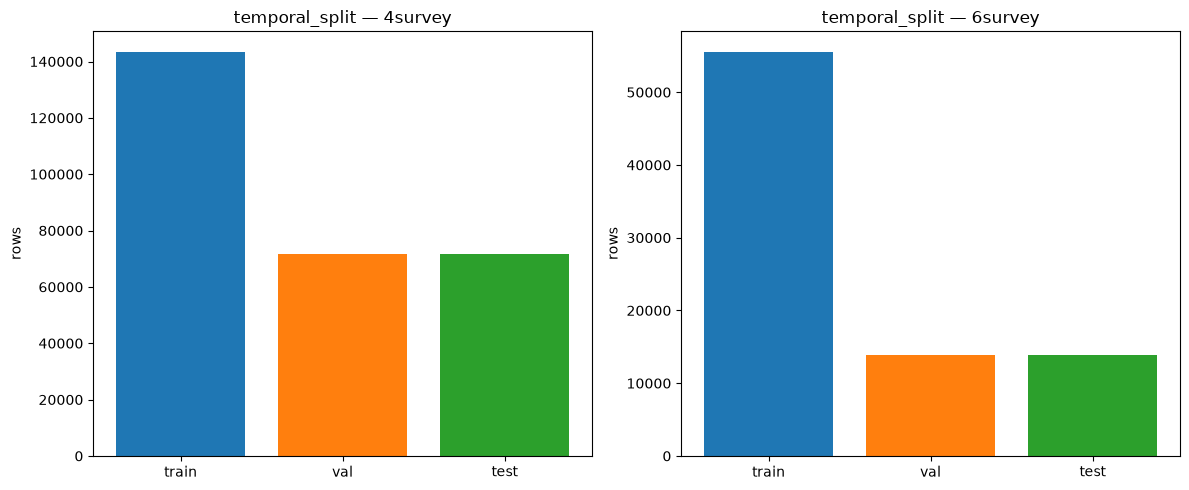

In [13]:
TEMPORAL_YEARS = {
    "4survey": {"train_years": [2008, 2012], "val_years": [2021], "test_years": [2023]},
    "6survey": {"train_years": [2002, 2006, 2008, 2012], "val_years": [2021], "test_years": [2023]},
}

temporal_split_dfs = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cohort in zip(axes, COHORTS):
    df = master[cohort].copy()
    df["temporal_split"] = temporal_split(df, year_col="LiDAR_year", **TEMPORAL_YEARS[cohort])
    temporal_split_dfs[cohort] = df

    counts = df["temporal_split"].value_counts().reindex(["train", "val", "test"]).fillna(0)
    bar_colors = [SPLIT_COLORS[name] for name in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors)
    ax.set_title(f"temporal_split — {cohort}")
    ax.set_ylabel("rows")

    years_label = ", ".join(f"{name}={years}" for name, years in TEMPORAL_YEARS[cohort].items())
    print(f"{cohort}: {years_label}")

plt.tight_layout()
plt.show()

## 7. Save split assignments (CSV, for now)

These are exploration outputs, not formal model runs — saved under `data/interim/` for now
so they can be reloaded without rerunning this notebook. The real per-model split assignments
used for fitting/evaluating live under `outputs/splits/<cohort>/split_assignment.csv`, produced
by `models/baselines/run_baselines.py`.

In [14]:
demo_output_dir = project_root / "data" / "interim" / "split_visualisation_demo"
demo_output_dir.mkdir(parents=True, exist_ok=True)

demo_columns = ["identification", "blk", "cpmt", "x", "y"]

for cohort in COHORTS:
    spatial_out_path = demo_output_dir / f"spatial_block_split_{cohort}.csv"
    spatial_split_dfs[cohort][demo_columns + ["spatial_split"]].to_csv(spatial_out_path, index=False)
    print(f"Saved -> {spatial_out_path}")

    buffered_out_path = demo_output_dir / f"spatial_block_split_buffered_{cohort}.csv"
    buffered_split_dfs[cohort][demo_columns + ["buffered_split"]].to_csv(buffered_out_path, index=False)
    print(f"Saved -> {buffered_out_path}")

    temporal_out_path = demo_output_dir / f"temporal_split_{cohort}.csv"
    temporal_split_dfs[cohort][["identification", "LiDAR_year", "temporal_split"]].to_csv(temporal_out_path, index=False)
    print(f"Saved -> {temporal_out_path}")

Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/data/interim/split_visualisation_demo/spatial_block_split_4survey.csv
Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/data/interim/split_visualisation_demo/spatial_block_split_buffered_4survey.csv


Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/data/interim/split_visualisation_demo/temporal_split_4survey.csv
Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/data/interim/split_visualisation_demo/spatial_block_split_6survey.csv
Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/data/interim/split_visualisation_demo/spatial_block_split_buffered_6survey.csv
Saved -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/data/interim/split_visualisation_demo/temporal_split_6survey.csv
